In [3]:
# Core typing for the graph state (shared memory)
from typing import TypedDict, Optional

# LangGraph for workflow orchestration
from langgraph.graph import StateGraph, END

# LangChain components
from langchain_community.llms import HuggingFacePipeline
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate

# Hugging Face transformers pipeline
from transformers import pipeline

d:\nihal\datacamp\ML practice\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Define the Shared Graph State
# Each agent will update part of the shared GraphState.
# This acts as the communication medium among agents.

class GraphState(TypedDict, total=False):
    query: str
    expression: Optional[str]
    search_result: Optional[str]
    calc_result: Optional[str]
    summary: Optional[str]


In [5]:
#Initialize the Language Model

hf_gen = pipeline(
    "text-generation",
    model="google/flan-t5-base",  # or 'google/flan-t5-base,,, mistralai/Mistral-7B-Instruct-v0.2'
    max_new_tokens=128,
    temperature=0.3
)

# Wrap in a LangChain-compatible LLM interface
llm = HuggingFacePipeline(pipeline=hf_gen)


d:\nihal\datacamp\ML practice\ml_env\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'ElectraForCausalLM', 'ErnieForCausalLM', 'FalconForCausalLM', 'FuyuForCausalLM', 'GemmaForCausalLM', 'Gemma2ForC

In [6]:
#This agent mimics a web search and returns a mock result.
#In real-world cases, you could replace this with a DuckDuckGo or Tavily API search.

def search_agent(state: GraphState):
    query = state["query"]
    print(f" [Search Agent] Simulating search for: {query}")
    mock_results = {
        "Germany GDP 2023": "Germany's GDP in 2023 was approximately 4.5 trillion USD.",
        "France GDP 2023": "France's GDP in 2023 was approximately 3.0 trillion USD."
    }
    return {"search_result": mock_results.get(query, f"No data found for {query}")}


In [7]:

# Define prompt for the calculator
calc_prompt = PromptTemplate.from_template("Calculate the result of: {expression}")

def calculator_agent(state: GraphState):
    expression = state.get("expression", "")
    print(f"[Calculator Agent] Calculating: {expression}")
    
    # Create LLMChain for computation
    chain = LLMChain(llm=llm, prompt=calc_prompt)
    
    result = chain.run(expression=expression)
    return {"calc_result": result}



In [8]:
def summarizer_agent(state: GraphState):
    print("[Summarizer Agent] Summarizing results...")

      # Combine all text from previous agents
    text = f"{state.get('search_result', '')}\n{state.get('calc_result', '')}"

        # Create summarization prompt
    prompt = PromptTemplate.from_template("Summarize this briefly:\n{input_text}")  # variable name = input_text
    chain = LLMChain(llm=llm, prompt=prompt)
    summary = chain.run(input_text=text)  # matches input_text
    return {"summary": summary}




In [9]:
workflow = StateGraph(GraphState)

# Define agent nodes
workflow.add_node("search", search_agent)
workflow.add_node("calculator", calculator_agent)
workflow.add_node("summarizer", summarizer_agent)

# Define edges (execution flow)
workflow.set_entry_point("search")
workflow.add_edge("search", "calculator")
workflow.add_edge("calculator", "summarizer")
workflow.add_edge("summarizer", END)

# Compile the workflow
graph = workflow.compile()



In [10]:
input_state = {
    "query": "Germany GDP 2023",
    "expression": "5% of 4.5 trillion USD"
}

result = graph.invoke(input_state)
print("\n Final Summary:\n", result["summary"])


C:\Users\hp\AppData\Local\Temp\ipykernel_2240\2998806018.py:9: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  chain = LLMChain(llm=llm, prompt=calc_prompt)
C:\Users\hp\AppData\Local\Temp\ipykernel_2240\2998806018.py:11: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  result = chain.run(expression=expression)
d:\nihal\datacamp\ML practice\ml_env\Lib\site-packages\transformers\generation\configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.3` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


 [Search Agent] Simulating search for: Germany GDP 2023
[Calculator Agent] Calculating: 5% of 4.5 trillion USD
[Summarizer Agent] Summarizing results...


d:\nihal\datacamp\ML practice\ml_env\Lib\site-packages\transformers\generation\configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.3` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(



 Final Summary:
 Summarize this briefly:
Germany's GDP in 2023 was approximately 4.5 trillion USD.
Calculate the result of: 5% of 4.5 trillion USDom the stock market was 4.5 trillion dollars.


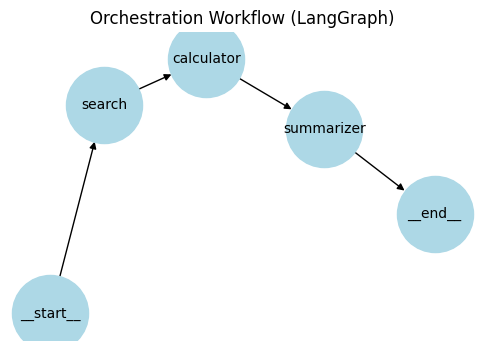

In [11]:
import matplotlib.pyplot as plt
import networkx as nx

# Retrieve the internal graph safely
g_obj = graph.get_graph()

# Try to detect the correct way to access edges
edges = []
try:
    edges = g_obj.edges
except Exception:
    try:
        edges = g_obj.edges()
    except Exception:
        pass

# Convert to a proper NetworkX DiGraph
nx_graph = nx.DiGraph()
for edge in edges:
    # Each edge should be a (source, target) tuple
    if isinstance(edge, (tuple, list)) and len(edge) >= 2:
        nx_graph.add_edge(edge[0], edge[1])

# --- Draw using matplotlib ---
plt.figure(figsize=(6, 4))
pos = nx.spring_layout(nx_graph, seed=42)
nx.draw_networkx(
    nx_graph,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=3000,
    font_size=10,
    arrows=True
)
plt.title("Orchestration Workflow (LangGraph)")
plt.axis("off")
plt.show()
